# Week 4 - Error Analysis & Model Improvement
**Project:** Sentiment Analysis of myBCA Mobile Banking App Reviews
**Author:** Elvia Aptanisa
**Week:** 4
**Purpose:** Analyze misclassified reviews to understand model weaknesses, then prepare findings for the final report.

---

## Step 1 - Install & Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import re
import string

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2 - Reload Dataset & Preprocess

In [4]:
df = pd.read_csv('mybca_reviews.csv')
df = df.drop_duplicates(subset='review', keep='first')

def clean_text_light(text):
    text = str(text).lower()
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_clean'] = df['review'].apply(clean_text_light)
df = df[df['review_clean'].str.strip() != '']
df = df.dropna(subset=['review_clean'])

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print(f"Dataset ready: {len(df)} reviews")
print(f"\nLabel mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {label} → {i}")

Dataset ready: 4267 reviews

Label mapping:
  Negative → 0
  Neutral → 1
  Positive → 2


## Step 3 - Tokenize & Split Data

In [5]:
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['review_clean'])

sequences = tokenizer.texts_to_sequences(df['review_clean'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

_, df_test = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df['label']
)

print(f"Data ready!")
print(f"Test set: {len(X_test)} reviews")

Data ready!
Test set: 641 reviews


## Step 4 - Load Saved Model

In [9]:
model = load_model('bilstm_sentiment_model.keras')
print("Model loaded successfully!")
model.summary()

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,995,083 (7.61 MB)

 Trainable params: 665,027 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,330,056 (5.07 MB)

## Step 5 - Error Analysis

In [10]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

df_test = df_test.reset_index(drop=True)
df_results = df_test.copy()
df_results['predicted'] = le.inverse_transform(y_pred)
df_results['actual'] = le.inverse_transform(y_test)
df_results['correct'] = df_results['predicted'] == df_results['actual']

print(f"Predictions done!")
print(f"Total test reviews : {len(df_results)}")
print(f"Correct predictions: {df_results['correct'].sum()}")
print(f"Wrong predictions  : {(~df_results['correct']).sum()}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Predictions done!
Total test reviews : 641
Correct predictions: 405
Wrong predictions  : 236


In [11]:
df_wrong = df_results[df_results['correct'] == False].reset_index(drop=True)

print(f"Total misclassified: {len(df_wrong)}")
print(f"\nMisclassification breakdown:")
print(df_wrong.groupby(['actual', 'predicted']).size().reset_index(name='count'))

Total misclassified: 236

Misclassification breakdown:
     actual predicted  count
0  Negative   Neutral    111
1  Negative  Positive     16
2   Neutral  Negative     30
3   Neutral  Positive      8
4  Positive  Negative     42
5  Positive   Neutral     29


In [12]:
print("=== MISCLASSIFIED EXAMPLES ===\n")

for actual in ['Negative', 'Neutral', 'Positive']:
    subset = df_wrong[df_wrong['actual'] == actual].head(3)
    print(f"--- Actual: {actual} ---")
    for _, row in subset.iterrows():
        print(f"Review    : {row['review']}")
        print(f"Predicted : {row['predicted']}")
        print()

=== MISCLASSIFIED EXAMPLES ===

--- Actual: Negative ---
Review    : jadi semakin lemot aplikasi nya sudah banyak yang mengeluh untuk aplikasi ini tlg di perbaiki
Predicted : Neutral

Review    : min buka aplikasinya sekarang lemot babget min,malah sekarang jadi susah banget buat login
Predicted : Neutral

Review    : mau bikin malah ga bisa verivikasi wajah ... developer apalah tulisan nya kacau
Predicted : Neutral

--- Actual: Neutral ---
Review    : update mulu,heran
Predicted : Positive

Review    : i think the apps sangat ngelag jadinya dari hp saya pun tidak merespon, tolong klo memang mau menambahkan fitur, servernya pun di update agar tdk down karna klo spt ini trs saya bnr² gabisa utk transaksi dgn nyaman even I have spent money to buy my phone credit many times for OTP codes 😔 pls jgn suruh saya buat restart device atau bilang internet saya kurang stabil, sblm saya beri rating.. sdh saya lakukan yg anda suruh dan tetap aja.. so useless and better updating ur application
Predi

## Step 6 - Error Analysis Summary

ERROR ANALYSIS SUMMARY

Total test reviews    : 641
Correct predictions   : 405 (63.2%)
Incorrect predictions : 236 (36.8%)

Misclassification table:
  actual predicted  count
Negative   Neutral    111
Negative  Positive     16
 Neutral  Negative     30
 Neutral  Positive      8
Positive  Negative     42
Positive   Neutral     29


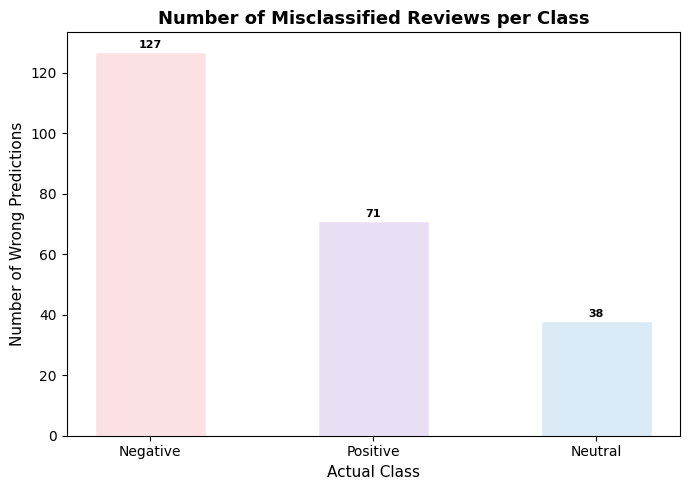

In [16]:
misclass = df_wrong.groupby(['actual', 'predicted']).size().reset_index(name='count')

print("ERROR ANALYSIS SUMMARY\n")
print(f"Total test reviews    : {len(df_results)}")
print(f"Correct predictions   : {df_results['correct'].sum()} ({df_results['correct'].mean()*100:.1f}%)")
print(f"Incorrect predictions : {(~df_results['correct']).sum()} ({(~df_results['correct']).mean()*100:.1f}%)")
print(f"\nMisclassification table:")
print(misclass.to_string(index=False))

wrong_by_class = df_wrong['actual'].value_counts()
colors = ['#fce1e4', '#e8dff5', '#daeaf6']

plt.figure(figsize=(7, 5))
bars = plt.bar(wrong_by_class.index, wrong_by_class.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, wrong_by_class.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of Misclassified Reviews per Class', fontsize=13, fontweight='bold')
plt.xlabel('Actual Class', fontsize=11)
plt.ylabel('Number of Wrong Predictions', fontsize=11)
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150)
plt.show()

## Step 7 - Key Findings from Error Analysis

**KEY FINDINGS FROM ERROR ANALYSIS**

1. LABEL NOISE
   Some reviews have misleading labels.
   Example: 'buruk lemot gajelas' labeled as Positive (high star rating)
   but the text is clearly negative. This is because labeling
   was based on star ratings, not actual text content.

2. AMBIGUOUS NEGATIVE REVIEWS
   Many Negative reviews use polite or mild language.
   Example: 'jadi semakin lemot, tlg diperbaiki'
   Model predicted Neutral because no strong negative words.

3. NEUTRAL CLASS DIFFICULTY
   Neutral reviews often contain both positive and negative opinions.
   Example: long review praising features but complaining about lag.
   Model predicted Positive because positive words dominated.

4. INFORMAL LANGUAGE
   Reviews with heavy slang, mixed language, or emoji
   are harder for the model to classify correctly.

5. FUTURE IMPROVEMENT
   - Use IndoBERT (pre-trained Indonesian BERT) for better context understanding
   - Manual labeling instead of star-rating-based labeling
   - Collect more Neutral class data to balance the dataset